#Exercises XP

Exercice 1 — Deep Learning vs Machine Learning traditionnel

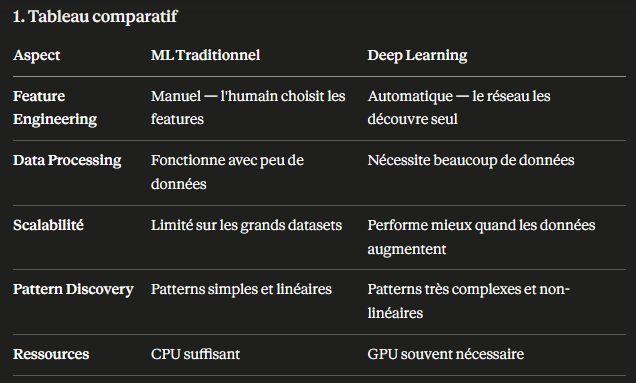

2. Exemples réels

- ML traditionnel est meilleur pour :

Prédire le prix d'une maison selon sa superficie et son quartier → données structurées, peu de variables, modèle simple (régression linéaire)

- Deep Learning est meilleur pour :

Reconnaître un visage sur une photo → données non structurées (pixels), patterns extrêmement complexes

3. Paragraphe — DL et données non structurées

Le Deep Learning excelle sur les données non structurées comme les images, le texte et l'audio car il peut apprendre automatiquement des représentations hiérarchiques. Par exemple, pour une image, les premières couches détectent des bords, les suivantes des formes, puis des objets complets. Le ML traditionnel nécessiterait qu'un expert extraie manuellement ces features, ce qui est impossible à grande échelle. C'est pourquoi le DL domine dans des domaines comme la vision par ordinateur et le traitement du langage naturel.

Exercice 2 — Diagramme ANN

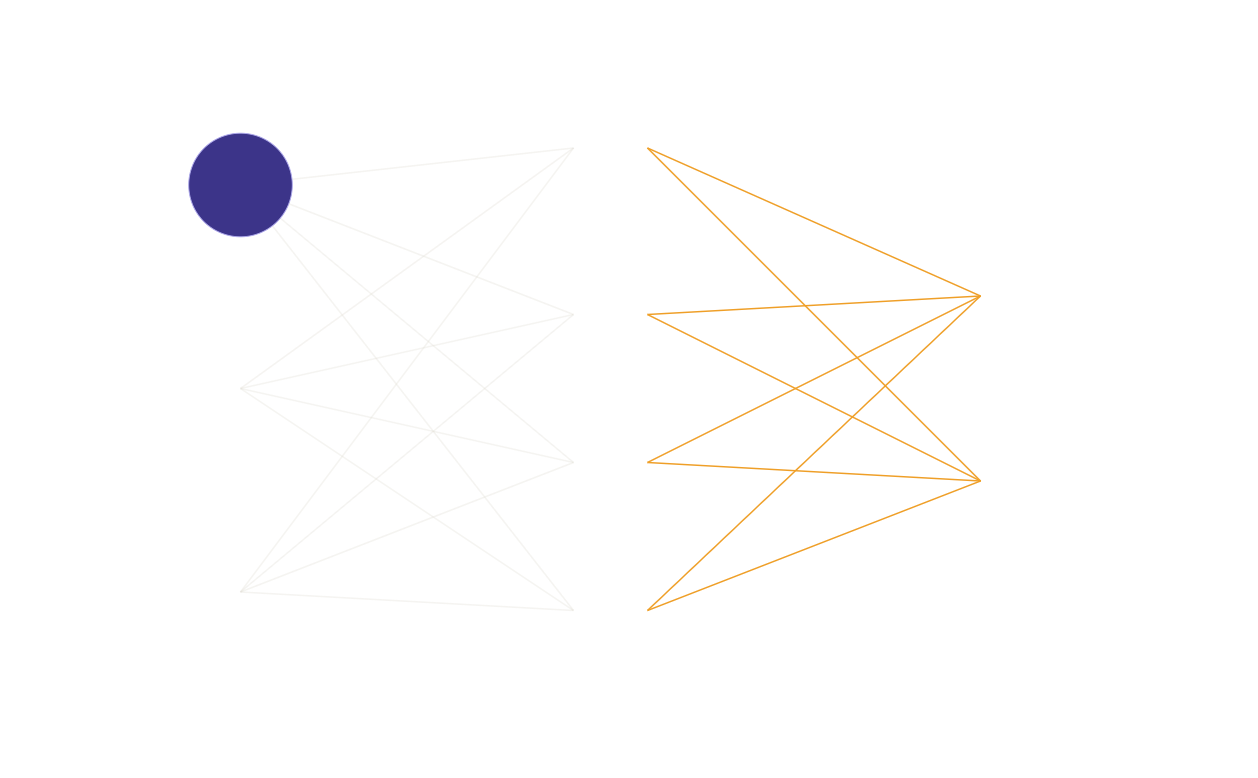

- Description du flux d'information

Les données entrent par la couche d'entrée (x₁, x₂, x₃). Chaque neurone envoie son signal à tous les neurones de la couche cachée via des connexions pondérées (poids w) auxquelles on ajoute un biais b. La couche cachée applique une fonction d'activation (ReLU) sur la somme pondérée, puis transmet le résultat à la couche de sortie. La couche de sortie applique Softmax pour produire des probabilités finales (y₁, y₂).

Exercice 3 — Créer et visualiser un dataset avec bruit

Nombre de points : 20
x : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1 -0.   0.1  0.2  0.3
  0.4  0.5  0.6  0.7  0.8  0.9]
y : [-0.9118 -0.79   -0.5911 -0.378  -0.2666 -0.2989 -0.1125 -0.0976 -0.0452
  0.0105  0.0072  0.0627 -0.0019 -0.0839 -0.1378 -0.2333 -0.2853 -0.5003
 -0.6243 -0.8527]


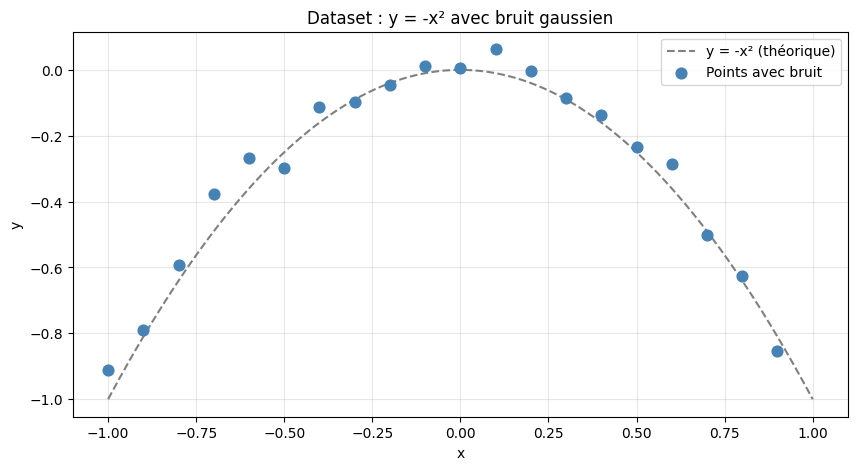


Train : 12 points | x de -1.0 à 0.1
Test  : 8  points | x de 0.2  à 0.9


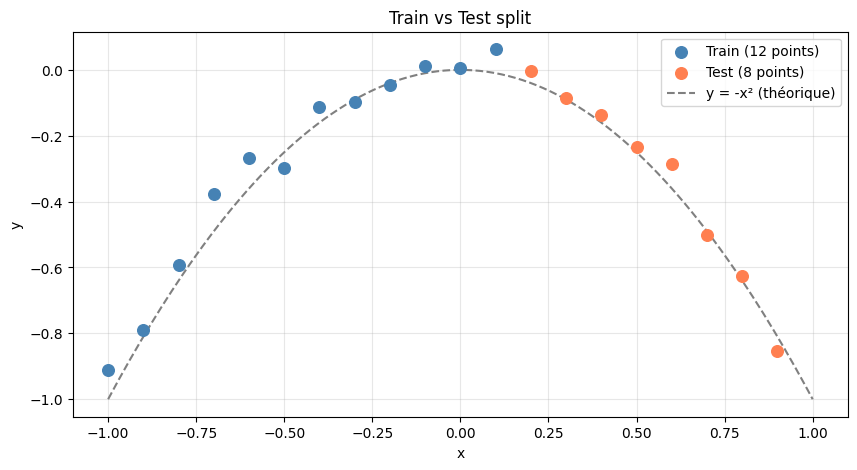

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# ============================================================
# ÉTAPE 1 — Créer le dataset
# ============================================================
np.random.seed(0)

x = np.arange(-1, 1, 0.1)          # 20 points de -1 à 1
y = -x**2 + np.random.normal(0, 0.05, len(x))  # y = -x² + bruit

print(f"Nombre de points : {len(x)}")
print(f"x : {x.round(2)}")
print(f"y : {y.round(4)}")

# ============================================================
# ÉTAPE 2 — Visualiser avec scatter plot
# ============================================================
plt.figure(figsize=(10, 5))

# Courbe théorique parfaite (sans bruit)
x_smooth = np.linspace(-1, 1, 200)
plt.plot(x_smooth, -x_smooth**2,
         color='gray',
         linestyle='--',
         label='y = -x² (théorique)',
         linewidth=1.5)

# Points avec bruit
plt.scatter(x, y,
            color='steelblue',
            s=60,
            zorder=5,
            label='Points avec bruit')

plt.title('Dataset : y = -x² avec bruit gaussien')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# ÉTAPE 3 — Séparer train / test
# ============================================================
x_train = x[:12]   # 12 premiers points
y_train = y[:12]

x_test = x[12:]    # 8 derniers points
y_test = y[12:]

print(f"\nTrain : {len(x_train)} points | x de {x_train[0]:.1f} à {x_train[-1]:.1f}")
print(f"Test  : {len(x_test)}  points | x de {x_test[0]:.1f}  à {x_test[-1]:.1f}")

# Visualiser train vs test
plt.figure(figsize=(10, 5))
plt.scatter(x_train, y_train,
            color='steelblue',
            s=70,
            label=f'Train ({len(x_train)} points)',
            zorder=5)
plt.scatter(x_test, y_test,
            color='coral',
            s=70,
            label=f'Test ({len(x_test)} points)',
            zorder=5)
plt.plot(x_smooth, -x_smooth**2,
         color='gray',
         linestyle='--',
         label='y = -x² (théorique)',
         linewidth=1.5)
plt.title('Train vs Test split')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Exercice 4 — Polynomial Regression et Overfitting

COMPARAISON DES DEGRÉS POLYNOMIAUX


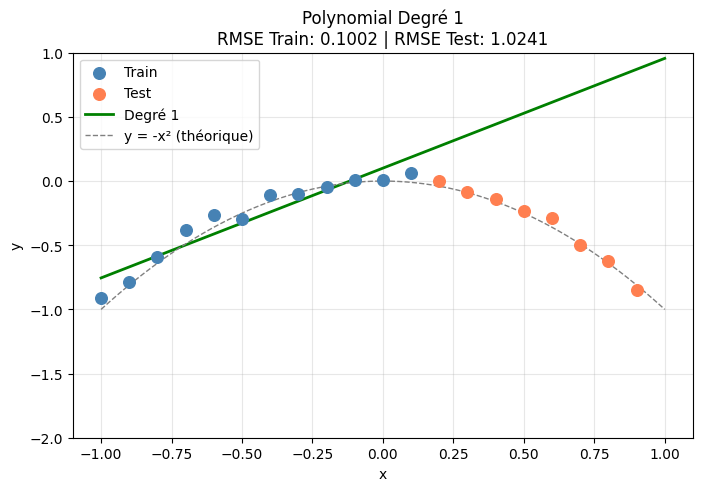

Degré  1 → RMSE Train: 0.1002 | RMSE Test: 1.0241


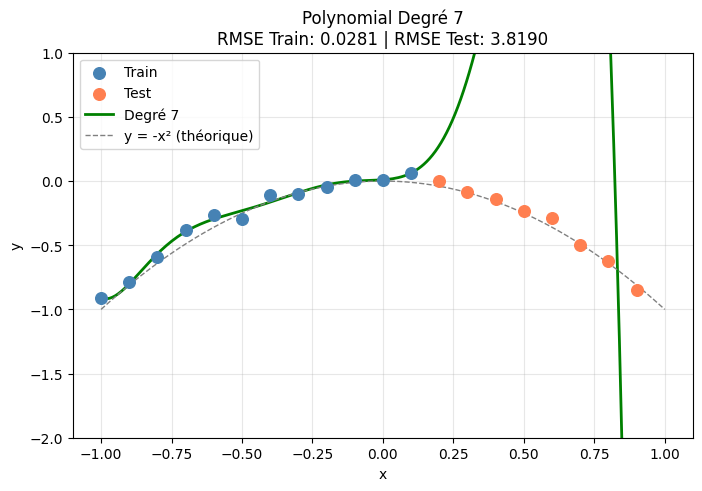

Degré  7 → RMSE Train: 0.0281 | RMSE Test: 3.8190


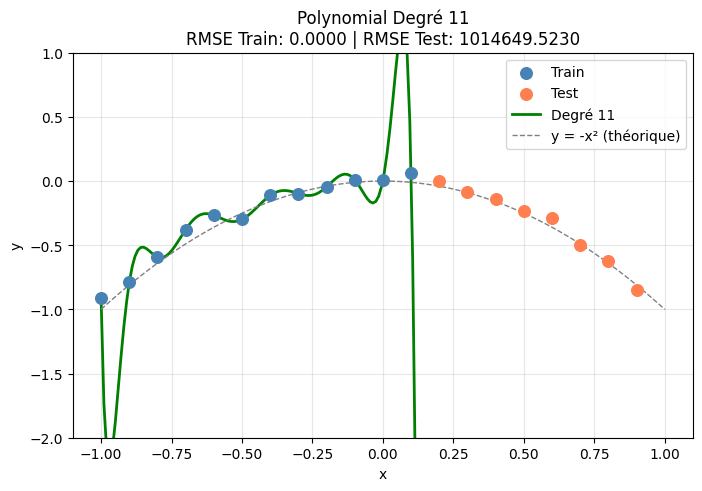

Degré 11 → RMSE Train: 0.0000 | RMSE Test: 1014649.5230


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# ============================================================
# DONNÉES (reprises de l'exercice 3)
# ============================================================
np.random.seed(0)
x = np.arange(-1, 1, 0.1)
y = -x**2 + np.random.normal(0, 0.05, len(x))

x_train, y_train = x[:12], y[:12]
x_test,  y_test  = x[12:], y[12:]

x_smooth = np.linspace(-1, 1, 200)

# ============================================================
# ÉTAPE 1 — Fonction polynomial_fit
# ============================================================
def polynomial_fit(degree):
    """
    Prend un degré et retourne les coefficients
    du polynôme qui fit le mieux les données d'entraînement
    """
    coeffs = np.polyfit(x_train, y_train, degree)
    # np.polyfit → trouve les coefficients a, b, c...
    # qui minimisent l'erreur sur les données train
    return coeffs

# ============================================================
# ÉTAPE 2 — Fonction plot_polyfit
# ============================================================
def plot_polyfit(degree):
    """
    Affiche le train set, test set et la courbe polynomiale
    pour un degré donné
    """
    coeffs = polynomial_fit(degree)

    # np.poly1d transforme les coefficients en fonction évaluable
    poly_func = np.poly1d(coeffs)

    # Prédictions
    y_train_pred = poly_func(x_train)
    y_test_pred  = poly_func(x_test)

    # Erreurs
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test  = np.sqrt(mean_squared_error(y_test,  y_test_pred))

    # Visualisation
    plt.figure(figsize=(8, 5))

    # Points
    plt.scatter(x_train, y_train,
                color='steelblue', s=70, zorder=5,
                label='Train')
    plt.scatter(x_test, y_test,
                color='coral', s=70, zorder=5,
                label='Test')

    # Courbe polynomiale
    plt.plot(x_smooth, poly_func(x_smooth),
             color='green', linewidth=2,
             label=f'Degré {degree}')

    # Courbe théorique
    plt.plot(x_smooth, -x_smooth**2,
             color='gray', linestyle='--',
             linewidth=1, label='y = -x² (théorique)')

    plt.title(
        f'Polynomial Degré {degree}\n'
        f'RMSE Train: {rmse_train:.4f} | RMSE Test: {rmse_test:.4f}'
    )
    plt.xlabel('x')
    plt.ylabel('y')
    plt.ylim(-2, 1)     # Fixer l'axe y pour comparer facilement
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Degré {degree:2d} → RMSE Train: {rmse_train:.4f} | RMSE Test: {rmse_test:.4f}")
    return rmse_train, rmse_test

# ============================================================
# ÉTAPE 3 — Visualiser degrés 1, 7 et 11
# ============================================================
print("=" * 50)
print("COMPARAISON DES DEGRÉS POLYNOMIAUX")
print("=" * 50)

for deg in [1, 7, 11]:
    plot_polyfit(deg)

Exercice 5 — Cross-Validation pour trouver le degré optimal

 Degré |   RMSE Train |    RMSE Test
     1 |     0.100226 |     1.024071 OPTIMAL
     2 |     0.041146 |     0.125781 OPTIMAL
     3 |     0.037337 |     0.769652
     4 |     0.036838 |     1.700233
     5 |     0.034942 |     6.206938
     6 |     0.028372 |    58.827475
     7 |     0.028134 |     3.819049
     8 |     0.027556 |   523.816993
     9 |     0.020865 | 10165.845299
    10 |     0.020599 | 25560.431510
    11 |     0.000000 | 1014649.522960

 Meilleur degré : 2
   RMSE test minimum : 0.125781
   → Confirme que y = -x² est le vrai modèle sous-jacent !


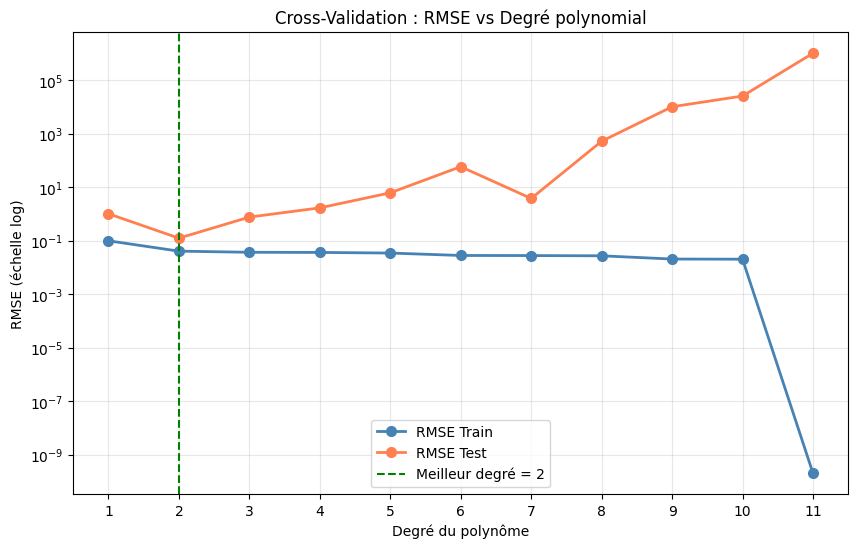

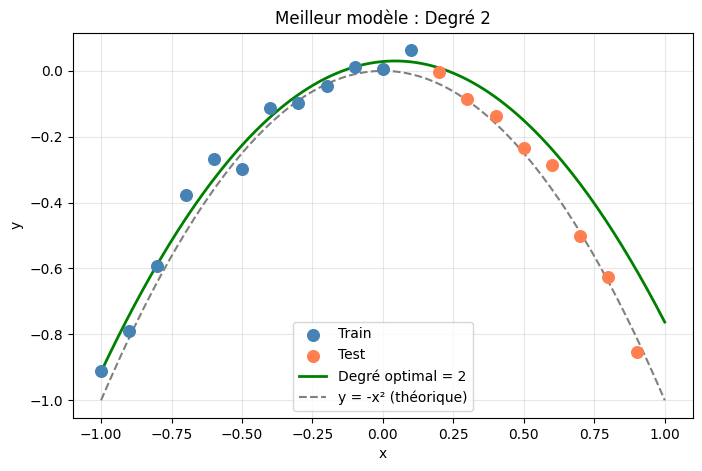

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# ============================================================
# DONNÉES
# ============================================================
np.random.seed(0)
x = np.arange(-1, 1, 0.1)
y = -x**2 + np.random.normal(0, 0.05, len(x))

x_train, y_train = x[:12], y[:12]
x_test,  y_test  = x[12:], y[12:]

# ============================================================
# ÉTAPE 1 — Boucle sur les degrés 1 à 11
# ============================================================
results = []  # On stocke (degré, rmse_train, rmse_test)

print("=" * 55)
print(f"{'Degré':>6} | {'RMSE Train':>12} | {'RMSE Test':>12}")
print("=" * 55)

for degree in range(1, 12):
    # Fit sur le train
    coeffs   = np.polyfit(x_train, y_train, degree)
    poly_func = np.poly1d(coeffs)

    # Prédictions
    y_train_pred = poly_func(x_train)
    y_test_pred  = poly_func(x_test)

    # RMSE
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test  = np.sqrt(mean_squared_error(y_test,  y_test_pred))

    results.append((degree, rmse_train, rmse_test))

    # Indicateur visuel
    flag = " OPTIMAL" if rmse_test == min(
        r[2] for r in results) else ""
    print(f"{degree:>6} | {rmse_train:>12.6f} | {rmse_test:>12.6f}{flag}")

print("=" * 55)

# ============================================================
# ÉTAPE 2 — Extraire les résultats
# ============================================================
degrees    = [r[0] for r in results]
rmse_train = [r[1] for r in results]
rmse_test  = [r[2] for r in results]

# Meilleur degré
best_degree = degrees[rmse_test.index(min(rmse_test))]
print(f"\n Meilleur degré : {best_degree}")
print(f"   RMSE test minimum : {min(rmse_test):.6f}")
print(f"   → Confirme que y = -x² est le vrai modèle sous-jacent !")

# ============================================================
# ÉTAPE 3 — Visualiser RMSE vs Degré (échelle log)
# ============================================================
plt.figure(figsize=(10, 6))

plt.plot(degrees, rmse_train,
         'o-', color='steelblue',
         linewidth=2, markersize=7,
         label='RMSE Train')

plt.plot(degrees, rmse_test,
         'o-', color='coral',
         linewidth=2, markersize=7,
         label='RMSE Test')

# Marquer le meilleur degré
plt.axvline(x=best_degree,
            color='green',
            linestyle='--',
            linewidth=1.5,
            label=f'Meilleur degré = {best_degree}')

plt.yscale('log')   # Échelle logarithmique !
plt.xticks(degrees)
plt.xlabel('Degré du polynôme')
plt.ylabel('RMSE (échelle log)')
plt.title('Cross-Validation : RMSE vs Degré polynomial')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# ÉTAPE 4 — Visualiser le meilleur fit
# ============================================================
coeffs_best = np.polyfit(x_train, y_train, best_degree)
poly_best   = np.poly1d(coeffs_best)
x_smooth    = np.linspace(-1, 1, 200)

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train,
            color='steelblue', s=70,
            zorder=5, label='Train')
plt.scatter(x_test, y_test,
            color='coral', s=70,
            zorder=5, label='Test')
plt.plot(x_smooth, poly_best(x_smooth),
         color='green', linewidth=2,
         label=f'Degré optimal = {best_degree}')
plt.plot(x_smooth, -x_smooth**2,
         color='gray', linestyle='--',
         linewidth=1.5, label='y = -x² (théorique)')

plt.title(f'Meilleur modèle : Degré {best_degree}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()